<a href="https://colab.research.google.com/github/zakari90/-DataAnalysis/blob/main/Students_performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

path ="/content/drive/MyDrive/hsoub ai/StudentsPerformance.csv"
df = pd.read_csv(path)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [ ]:
df


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [ ]:
df.isnull().sum()


,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.nunique()

,0
gender,2
race/ethnicity,5
parental level of education,6
lunch,2
test preparation course,2
math score,81
reading score,72
writing score,77


 1see data,
 ask related questions to understand the data,
 and clean the data from null and duplicated values

In [ ]:
print(f"Number of duplicate rows before removal: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Number of duplicate rows after removal: {df.duplicated().sum()}")

Number of duplicate rows before removal: 0
Number of duplicate rows after removal: 0


In [ ]:
df['gender'].unique()

array(['female', 'male'], dtype=object)

In [ ]:
# df.columns returns an Index object containing the names of all columns in the DataFrame 'df'.
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [ ]:
df.rename(columns={'race/ethnicity' :'race',
                   'parental level of education':'parental_education',
                   'test preparation course':'test_preparation',
                   'math score':'math_score',
                   'reading score':'reading_score',
                   'writing score':'writing_score'

                   }, inplace=True)

In [ ]:
df.columns

Index(['gender', 'race', 'parental_education', 'lunch', 'test_preparation',
       'math_score', 'reading_score', 'writing_score'],
      dtype='object')

In [ ]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [ ]:
reading_max_score = df[df['reading_score']== 100]['reading_score'].count()
writing_max_score = df[df['writing_score']== 100]['writing_score'].count()
math_max_score = df[df['math_score']== 100]['math_score'].count()
print(f"Number of students with maximum scores in reading: {reading_max_score}")
print(f"Number of students with maximum scores in writing: {writing_max_score}")
print(f"Number of students with maximum scores in math: {math_max_score}")

Number of students with maximum scores in reading: 17
Number of students with maximum scores in writing: 14
Number of students with maximum scores in math: 7


In [ ]:
reading_successful_students = df[df['reading_score']>= 50]['reading_score'].count()
writing_successful_students = df[df['writing_score']>= 50]['writing_score'].count()
math_max_successful_students = df[df['math_score']>= 50]['math_score'].count()

print(f"Number of students with successful scores in reading: {reading_successful_students}")
print(f"Number of students with successful scores in writing: {writing_successful_students}")
print(f"Number of students with successful scores in math: {math_max_successful_students}")

Number of students with successful scores in reading: 910
Number of students with successful scores in writing: 886
Number of students with successful scores in math: 865


In [ ]:
pass_grade = 50
df["pass_math"] ='yes'
filtr=(df['math_score']< pass_grade)
df.loc[filtr, 'pass_math'] = 'no' #update the pass_math column
df[['math_score', 'pass_math']].head()
#
df["pass_reading"] ='yes'
filtr=(df['reading_score']< pass_grade)
df.loc[filtr, 'pass_reading'] = 'no' #update the pass_math column
df[['reading_score', 'pass_reading']].head()
#
df["pass_writing"] ='yes'
filtr=(df['writing_score']< pass_grade)
df.loc[filtr, 'pass_writing'] = 'no' #update the pass_math column
df[['writing_score', 'pass_writing']].head()

,writing_score,pass_writing
0,74,yes
1,88,yes
2,93,yes
3,44,no
4,75,yes


In [ ]:
df

,gender,race,parental_education,lunch,test_preparation,math_score,reading_score,writing_score,pass_math,pass_reading,pass_writing
0,female,group B,bachelor's degree,standard,none,72,72,74,yes,yes,yes
1,female,group C,some college,standard,completed,69,90,88,yes,yes,yes
2,female,group B,master's degree,standard,none,90,95,93,yes,yes,yes
3,male,group A,associate's degree,free/reduced,none,47,57,44,no,yes,no
4,male,group C,some college,standard,none,76,78,75,yes,yes,yes
...,...,...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,yes,yes,yes
996,male,group C,high school,free/reduced,none,62,55,55,yes,yes,yes
997,female,group C,high school,free/reduced,completed,59,71,65,yes,yes,yes
998,female,group D,some college,standard,completed,68,78,77,yes,yes,yes


In [ ]:
pass_math_count = df.groupby('pass_math')["pass_math"].count()
# pass_math_count2 = df.groupby('pass_math').size()
# pass_math_count2
pass_reading_count = df.groupby('pass_reading')['pass_reading'].count()
pass_writing_count = df.groupby('pass_writing')['pass_writing'].count()

print("Math Pass Counts:")
display(pass_math_count)
print("\nReading Pass Counts:")
display(pass_reading_count)
print("\nWriting Pass Counts:")
display(pass_writing_count)




Math Pass Counts:


,pass_math
pass_math,
no,135
yes,865



Reading Pass Counts:


,pass_reading
pass_reading,
no,90
yes,910



Writing Pass Counts:


,pass_writing
pass_writing,
no,114
yes,886


Mean scores in math: 66.089
Mean scores in reading: 69.169
Mean scores in writing: 68.054


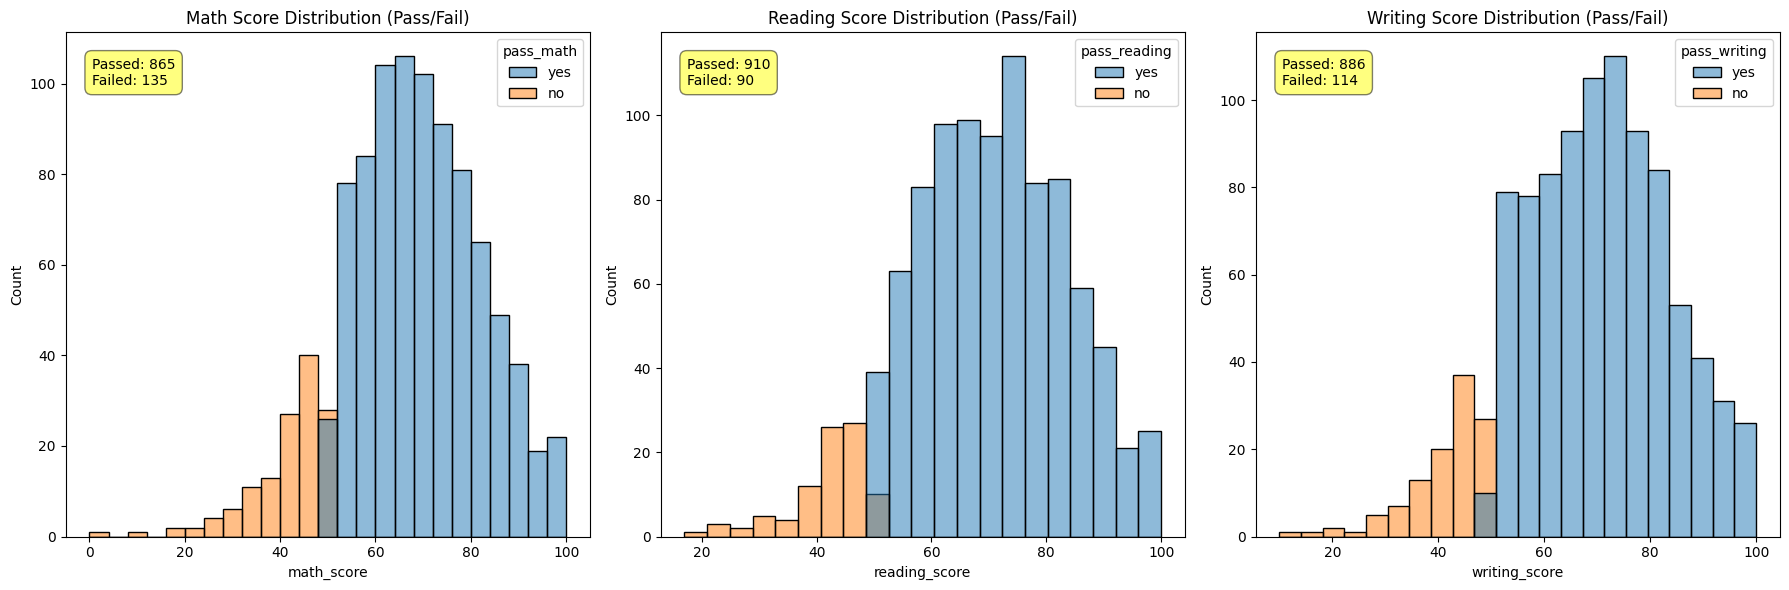

In [ ]:
fig, ax = plt.subplots(1,3,figsize=(18, 6)) # Increased figure size for better readability of annotations

sns.histplot(data=df, x='math_score', hue='pass_math', ax=ax[0])
sns.histplot(data=df, x='reading_score', hue='pass_reading' , ax =ax[1])
sns.histplot(data=df, x='writing_score', hue='pass_writing', ax =ax[2])

# Calculate pass/fail counts within this cell for self-containment
pass_math_count = df.groupby('pass_math')['pass_math'].count()
pass_reading_count = df.groupby('pass_reading')['pass_reading'].count()
pass_writing_count = df.groupby('pass_writing')['pass_writing'].count()

# Add annotations to math histogram
ax[0].text(0.05, 0.95, f"Passed: {pass_math_count.get('yes', 0)}\nFailed: {pass_math_count.get('no', 0)}", transform=ax[0].transAxes, fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))
ax[0].set_title('Math Score Distribution (Pass/Fail)') # Added title for clarity

# Add annotations to reading histogram
ax[1].text(0.05, 0.95, f"Passed: {pass_reading_count.get('yes', 0)}\nFailed: {pass_reading_count.get('no', 0)}", transform=ax[1].transAxes, fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))
ax[1].set_title('Reading Score Distribution (Pass/Fail)') # Added title for clarity

# Add annotations to writing histogram
ax[2].text(0.05, 0.95, f"Passed: {pass_writing_count.get('yes', 0)}\nFailed: {pass_writing_count.get('no', 0)}", transform=ax[2].transAxes, fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))
ax[2].set_title('Writing Score Distribution (Pass/Fail)') # Added title for clarity

plt.tight_layout() # Adjust layout to prevent labels from being cut off

math_mean = df['math_score'].mean()
reading_mean = df['reading_score'].mean()
writing_mean = df['writing_score'].mean()
print(f"Mean scores in math: {math_mean}")
print(f"Mean scores in reading: {reading_mean}")
print(f"Mean scores in writing: {writing_mean}")
plt.show()

Math Pass Counts:


,pass_math
pass_math,
no,135
yes,865



Reading Pass Counts:


,pass_reading
pass_reading,
no,90
yes,910



Writing Pass Counts:


,pass_writing
pass_writing,
no,114
yes,886


<Axes: xlabel='pass_writing', ylabel='count'>

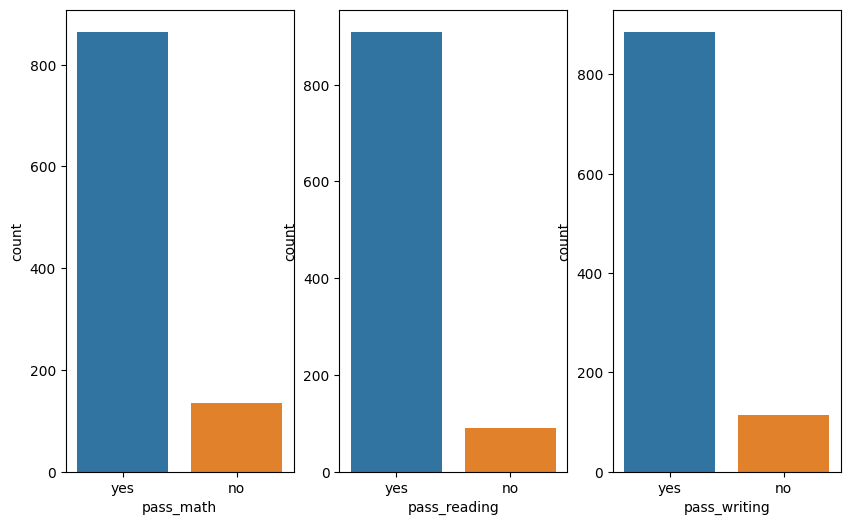

In [ ]:
fig, ax = plt.subplots(1,3,figsize=(10, 6))
pass_math_count = df.groupby('pass_math')["pass_math"].count()
pass_reading_count = df.groupby('pass_reading')['pass_reading'].count()
pass_writing_count = df.groupby('pass_writing')['pass_writing'].count()

print("Math Pass Counts:")
display(pass_math_count)
print("\nReading Pass Counts:")
display(pass_reading_count)
print("\nWriting Pass Counts:")
display(pass_writing_count)

sns.countplot(data=df, x='pass_math', hue='pass_math', ax=ax[0])
sns.countplot(data=df, x='pass_reading', hue='pass_reading', ax=ax[1])
sns.countplot(data=df, x='pass_writing', hue='pass_writing', ax=ax[2])


gender
female    518
male      482
Name: count, dtype: int64


Text(0.5, 1.0, 'Parental Education Distribution')

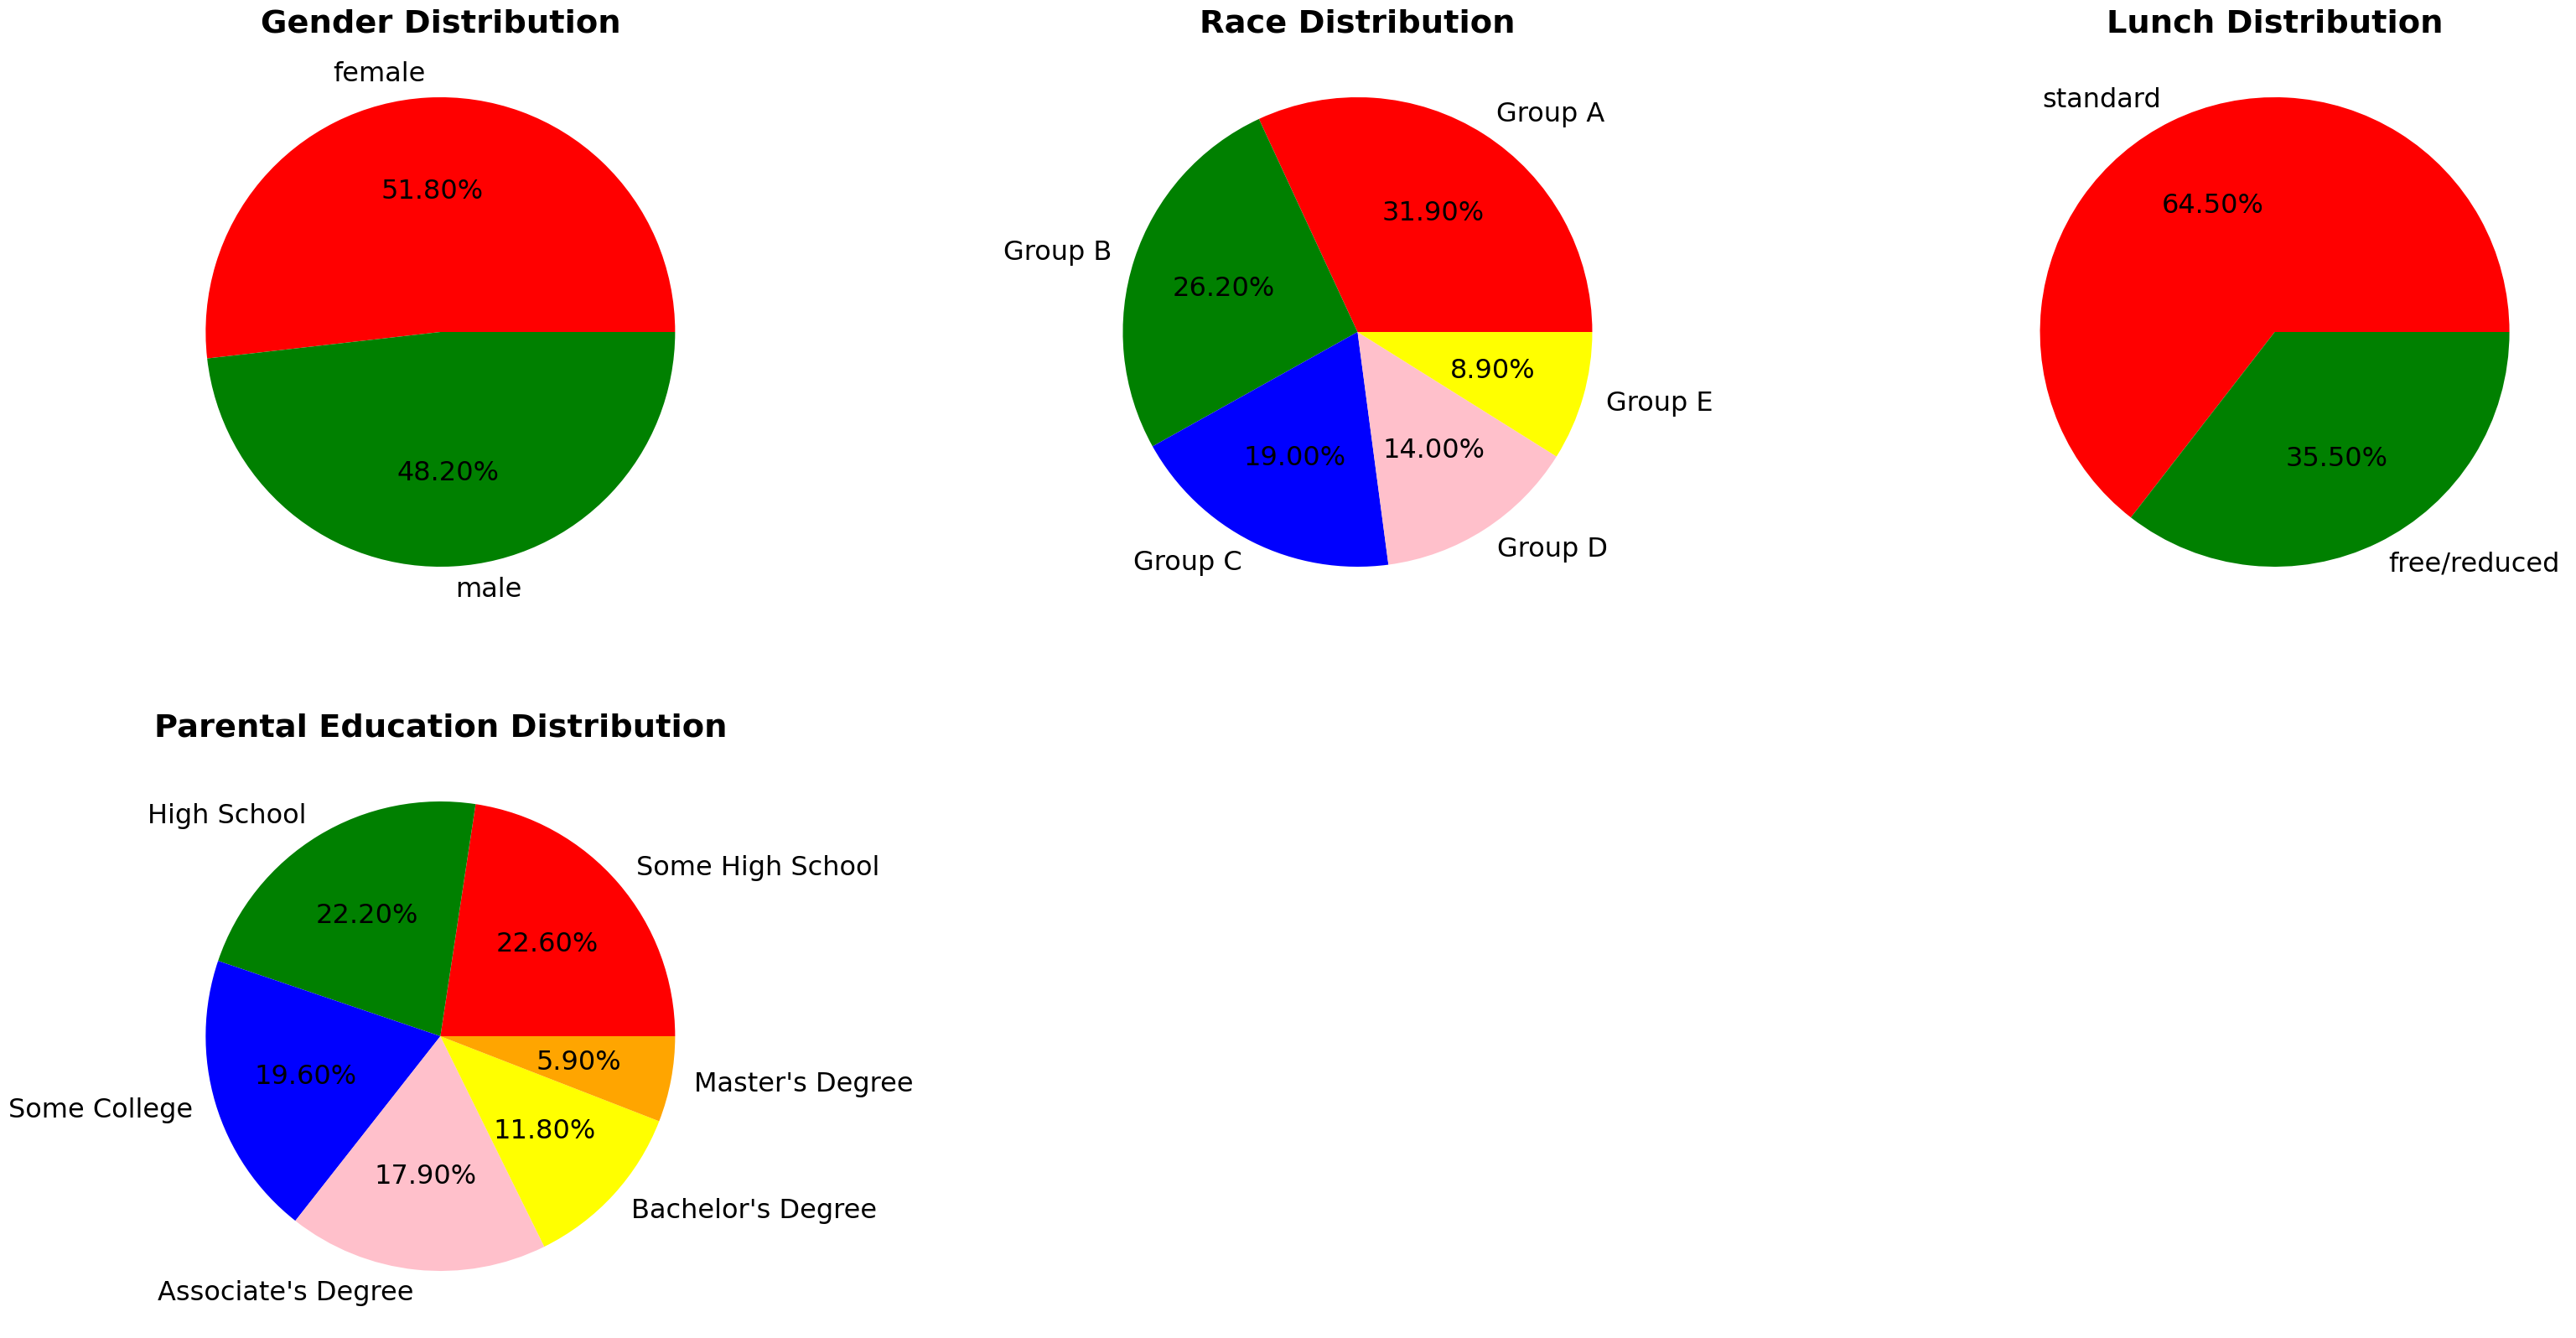

In [ ]:
plt.rcParams["figure.figsize"] =(40,20)
plt.rcParams["font.size"] =23

plt.subplot(2,3,1)
size = df["gender"].value_counts()
# print(size)
labels =size.index.to_list()
color =["red", "green"]
plt.pie(size, labels=labels, colors=color, autopct="%.2f%%")
plt.title("Gender Distribution" , fontweight ="bold")

plt.subplot(2,3,2)
size = df["race"].value_counts()
labels = "Group A", "Group B", "Group C", "Group D", "Group E"
color =["red", "green", "blue", "pink", "yellow"]
plt.pie(size, labels=labels, colors=color, autopct="%.2f%%")
plt.title("Race Distribution" , fontweight ="bold")

plt.subplot(2,3,3)
size = df["lunch"].value_counts()
labels = size.index.to_list()
color =["red", "green"]
plt.pie(size, labels=labels, colors=color, autopct="%.2f%%")
plt.title("Lunch Distribution" , fontweight ="bold")

plt.subplot(2,3,4)
size = df["parental_education"].value_counts()
labels = "Some High School", "High School", "Some College", "Associate's Degree", "Bachelor's Degree", "Master's Degree"
color =["red", "green", "blue", "pink", "yellow", "orange"]
plt.pie(size, labels=labels, colors=color, autopct="%.2f%%")
plt.title("Parental Education Distribution" , fontweight ="bold")

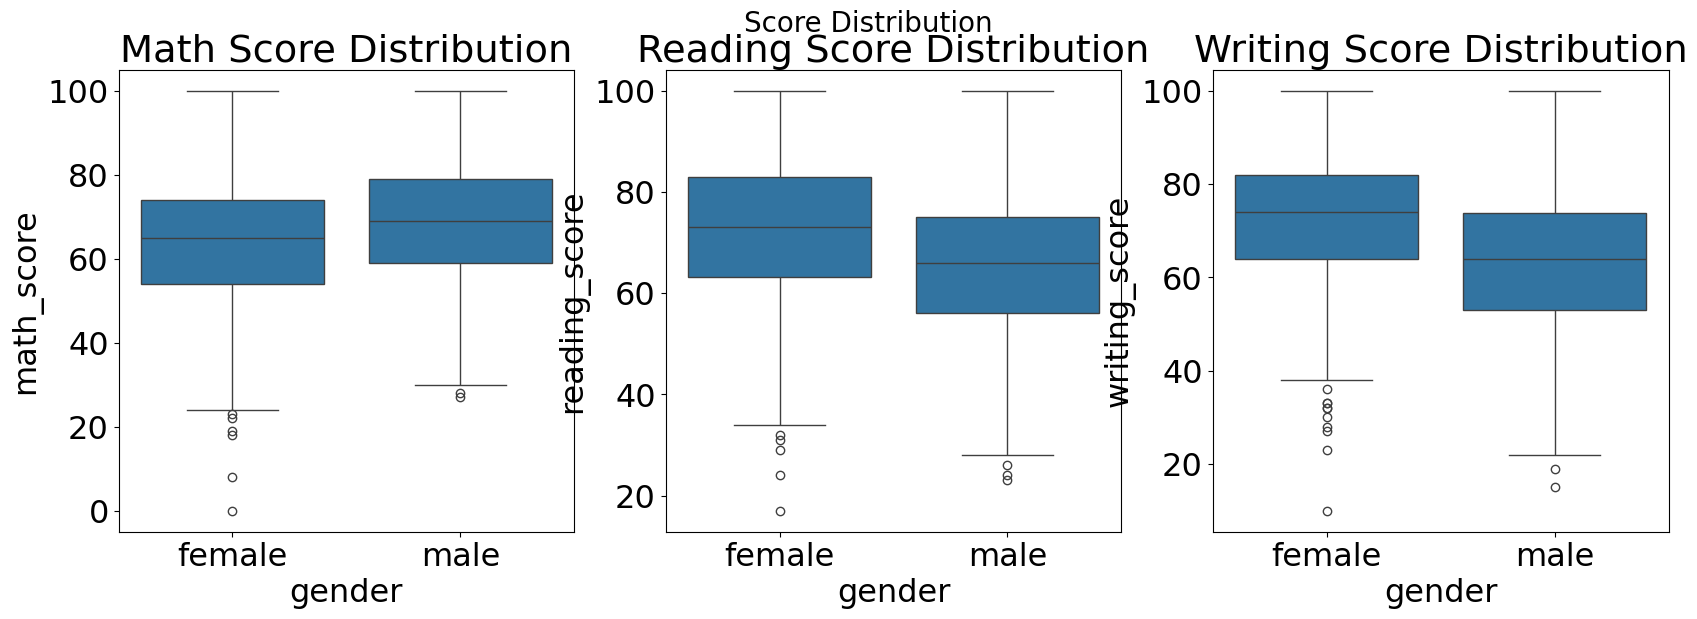

In [ ]:
fig , (ax1, ax2,ax3) = plt.subplots(1,3, figsize=(20, 6))
fig.suptitle("Score Distribution", fontsize = 20)

sns.boxplot(data=df, x='gender', y='math_score', ax=ax1)
ax1.title.set_text("Math Score Distribution")
sns.boxplot(data=df, x='gender', y='reading_score', ax=ax2)
ax2.title.set_text("Reading Score Distribution")
sns.boxplot(data=df, x='gender', y='writing_score', ax=ax3)
ax3.title.set_text("Writing Score Distribution")

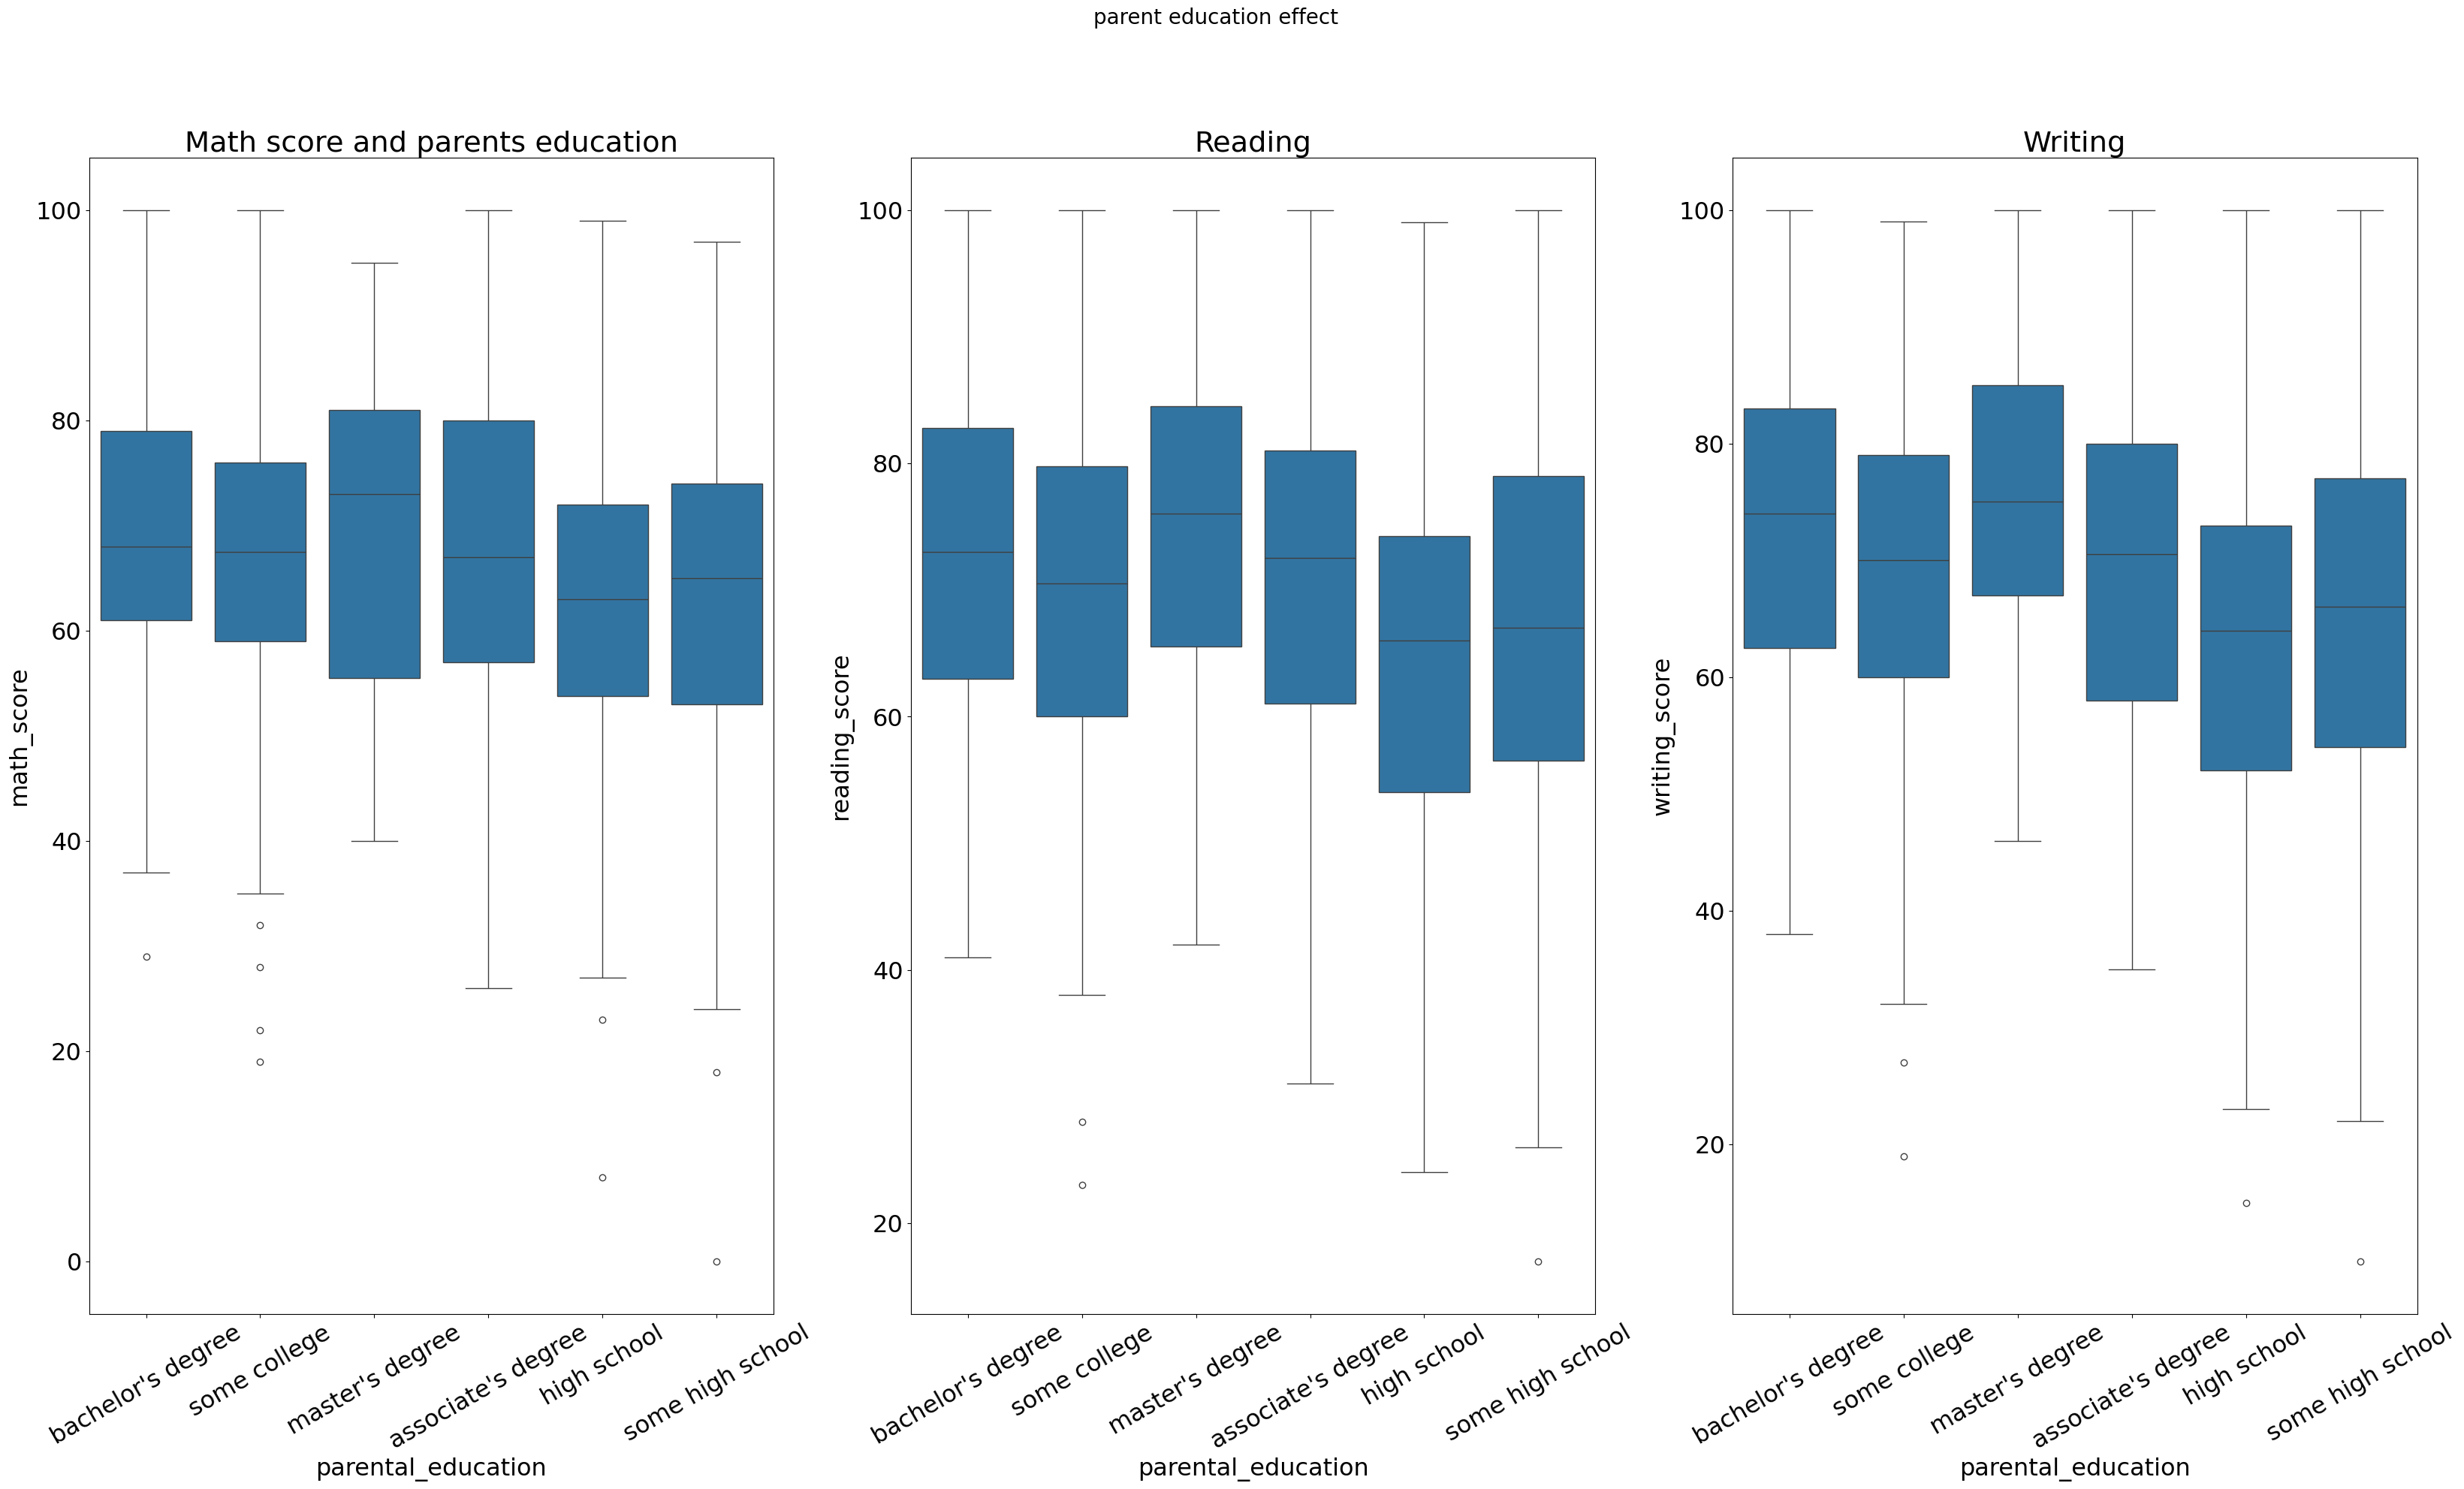

In [ ]:
fig , (ax1, ax2,ax3) = plt.subplots(1,3)
fig.suptitle("parent education effect", fontsize = 20)

sns.boxplot(data=df, x='parental_education', y='math_score', ax=ax1)
ax1.title.set_text("Math score and parents education")
ax1.tick_params(axis='x', rotation=30)

sns.boxplot(data=df, x='parental_education', y='reading_score', ax=ax2)
ax2.title.set_text("Reading")
ax2.tick_params(axis='x', rotation=30)

sns.boxplot(data=df, x='parental_education', y='writing_score', ax=ax3)
ax3.title.set_text("Writing")
ax3.tick_params(axis='x', rotation=30)


